# Lung Sound Classification (HLS-CMDS)

Classifies **lung sound type** (Normal, Wheezing, Rhonchi, Coarse/Fine Crackles, Pleural Rub) from the [HLS-CMDS](https://doi.org/10.1109/IEEEDATA.2025.3566012) recordings, comparing a scikit-learn MLP on pooled log-mel features with a PyTorch CNN on full log-mel spectrograms.

## Setup

Imports: `pathlib` for file globbing, `pandas` to read the label CSVs, `librosa`/`numpy` for audio loading and feature extraction, `sklearn` for the train/test split and evaluation metrics, and `torch` for the CNN and training loop.

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np, pandas as pd, librosa, torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

## Configuration

`ROOT` points at the `HLS-CMDS/` dataset folder (see `README.md` for the download/layout instructions — it's gitignored because of the `.wav` files). Audio is resampled to `SAMPLE_RATE=8000` Hz and every clip is fixed to `SECS=6.0` s so all spectrograms come out the same shape; `N_MELS`/`N_FFT`/`HOP` control the mel-spectrogram resolution.

In [2]:
ROOT = Path("HLS-CMDS")
SAMPLE_RATE = 8000
HOP_LENGTH = 256
SECS = 10.0
N_MELS = 64
LENGTH_OF_FFT = 1024
RANDOM_STATE = 42

## Build the file index

Lung-labeled recordings come from two places: `LS/LS/*.wav` and the `L####.wav` files inside `Mix/Mix/` (the isolated lung component of each mixed recording, labeled by `Mix.csv`'s `Lung Sound ID`/`Lung Sound Type` columns, e.g. `L0001.wav`). Combining both sources gives 195 samples across 6 balanced classes instead of just the 50 in `LS.csv` alone.

Note: `LS.csv`'s own `Lung Sound ID` column doesn't reliably match the real filenames — it abbreviates Coarse Crackles as `G` and Fine Crackles as `C` (e.g. `M_G_LLA`), while the actual `.wav` files on disk use `CC`/`FC` (e.g. `M_CC_LLA.wav`). So for `LS/LS/` we decode the label directly from the filename's own code via a fixed `CODE2TYPE` table instead of joining on that ID column; `Mix.csv`'s numeric IDs (`L0001`, ...) don't have this problem and are looked up normally.

`CLASSES` is the sorted set of the 6 lung sound types, and `LABEL2IDX` maps each type name to the integer index used for training.

In [3]:
CODE2TYPE = {
    "N": "Normal", 
    "CC": "Coarse Crackles", 
    "FC": "Fine Crackles",
    "R": "Rhonchi", 
    "W": "Wheezing", 
    "PR": "Pleural Rub"
    }
mix_type = pd.read_csv(ROOT/"Mix.csv").set_index("Lung Sound ID")["Lung Sound Type"]

CLASSES = sorted(CODE2TYPE.values())
LABEL2IDX = {c: i for i, c in enumerate(CLASSES)}

def build_index():
    recs = [(wav, LABEL2IDX[CODE2TYPE[wav.stem.split("_")[1]]]) for wav in (ROOT/"LS"/"LS").glob("*.wav")]
    recs += [(wav, LABEL2IDX[mix_type[wav.stem]]) for wav in (ROOT/"Mix"/"Mix").glob("L*.wav")]
    return recs

## Feature extraction

`to_melspec` turns a `.wav` file into a normalized log-mel spectrogram:

1. Load audio mono at `SAMPLE_RATE` and center-crop or zero-pad it to exactly `SECS` seconds, so every clip yields a fixed-size input.
2. Compute a mel-spectrogram and convert power to decibels (`power_to_db`).
3. Standardize (zero mean, unit variance) so all clips are on a comparable scale.

The MLP uses `to_features`, which pools each spectrogram into mean and standard deviation values per mel band. The CNN uses the full 2-D spectrogram so it can learn local time-frequency patterns.

In [4]:
def to_melspec(path):
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    n = int(SECS*SAMPLE_RATE)
    y = np.pad(y, (0, n-len(y))) if len(y) < n else y[(len(y)-n)//2:(len(y)-n)//2+n]
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_fft=LENGTH_OF_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    m = librosa.power_to_db(mel, ref=np.max)
    return ((m - m.mean()) / (m.std() + 1e-6)).astype(np.float32)


def to_features(path):
    spec = to_melspec(path)
    return np.concatenate([spec.mean(axis=1), spec.std(axis=1)]).astype(np.float32)


## Dataset

Thin `torch.utils.data.Dataset` wrapper: given a list of `(path, label)` pairs (from `build_index`), it lazily computes the log-mel spectrogram per item and returns it as a `(1, N_MELS, time)` float tensor plus its integer class label, ready for a `DataLoader`/CNN.

In [5]:
class LungSounds(Dataset):
    def __init__(self, recs):
        self.recs = recs
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        path, label = self.recs[i]
        return torch.from_numpy(to_melspec(path)).unsqueeze(0), label

In [6]:
recs = build_index()
print(Counter(CLASSES[l] for _, l in recs))
print("spectrogram shape:", LungSounds(recs)[0][0].shape)

Counter({'Normal': 40, 'Wheezing': 35, 'Pleural Rub': 34, 'Rhonchi': 31, 'Coarse Crackles': 28, 'Fine Crackles': 27})
spectrogram shape: torch.Size([1, 64, 313])


## Removing duplicate recordings

`Mix/Mix/L####.wav` isolates the lung component out of each heart+lung mixture, but the same lung recording gets reused across several different heart-sound pairings — and 45 of those isolated components are byte-for-byte identical to a file that also lives in `LS/LS/` (verified directly on the waveforms: `corrcoef` = 1.0, zero max absolute difference, not just a metadata coincidence). So the 195 `.wav` files reduce to only 94 acoustically unique lung sounds.

The deduplicated `.wav` files and their labels are also copied out to `HLS-CMDS/Unique/` and `HLS-CMDS/unique_lung_sounds.csv`, so group mates can work from the clean 94-clip set directly instead of re-running the hashing step themselves.

In [7]:
import hashlib, shutil

def audio_group_id(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()

seen, deduped = set(), []
for path, label in recs:
    gid = audio_group_id(path)
    if gid not in seen:
        seen.add(gid)
        deduped.append((path, label))

print(f"{len(recs)} recordings -> {len(deduped)} acoustically unique "
      f"({len(recs) - len(deduped)} duplicates dropped)")
recs = deduped

UNIQUE_DIR = ROOT/"Unique"
UNIQUE_DIR.mkdir(exist_ok=True)
for path, _ in recs:
    shutil.copy2(path, UNIQUE_DIR/path.name)

unique_df = pd.DataFrame(
    [{"filename": path.name, "label": CLASSES[label]} for path, label in recs]
)
unique_df.to_csv(ROOT/"unique_lung_sounds.csv", index=False)
print(f"Saved {len(unique_df)} deduplicated clips to {UNIQUE_DIR}/ "
      f"and labels to {ROOT/'unique_lung_sounds.csv'}")

195 recordings -> 94 acoustically unique (101 duplicates dropped)
Saved 94 deduplicated clips to HLS-CMDS/Unique/ and labels to HLS-CMDS/unique_lung_sounds.csv


## Multi-Layer Perceptron (scikit-learn)

Split `(features, label)` with a stratified `train_test_split`, holding out 20% as the test set. Tune an `MLPClassifier` with `GridSearchCV`, using `StratifiedKFold` as its `cv`. The classifier is wrapped in a `Pipeline` with a `StandardScaler` so feature scaling is refit on each fold's training data only. The grid searches over hidden layer size, activation, L2 penalty (`alpha`), and initial learning rate.

In [8]:
X = np.stack([to_features(path) for path, _ in recs])
y = np.array([label for _, label in recs])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=2000, early_stopping=False, random_state=RANDOM_STATE)),
])

param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],
    "mlp__learning_rate_init": [1e-3, 1e-2],
}

grid_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid, cv=grid_cv, scoring="accuracy", n_jobs=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy: %.3f" % grid.best_score_)

Best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001}
Best CV accuracy: 0.880


## MLP Evaluation

Refit on the full training split happens automatically inside `GridSearchCV` (`refit=True` by default), so `grid.best_estimator_` is ready to score on the held-out test set. Report per-class precision/recall/F1 and the confusion matrix, then run 5-fold cross-validation with the tuned hyperparameters over the entire dataset.

                 precision    recall  f1-score   support

Coarse Crackles       0.75      1.00      0.86         3
  Fine Crackles       1.00      0.33      0.50         3
         Normal       1.00      0.67      0.80         3
    Pleural Rub       0.80      1.00      0.89         4
        Rhonchi       0.75      1.00      0.86         3
       Wheezing       1.00      1.00      1.00         3

       accuracy                           0.84        19
      macro avg       0.88      0.83      0.82        19
   weighted avg       0.88      0.84      0.82        19



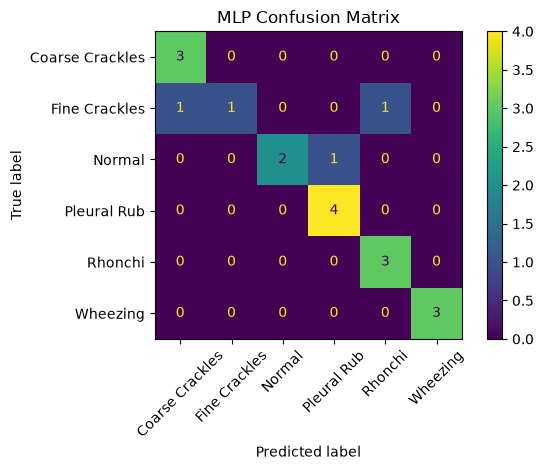

In [9]:
best_mlp = grid.best_estimator_
mlp_pred = best_mlp.predict(X_test)

print(classification_report(y_test, mlp_pred, target_names=CLASSES, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, mlp_pred, display_labels=CLASSES, xticks_rotation=45)
plt.title("MLP Confusion Matrix")
plt.tight_layout()
plt.show()

In [10]:
cv_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=2000, early_stopping=False, random_state=RANDOM_STATE).set_params(
        **{k.split("__", 1)[1]: v for k, v in grid.best_params_.items()}
    )),
])

eval_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_pipe, X, y, cv=eval_cv, scoring="accuracy", n_jobs=1)

print("Per-fold accuracy:", np.round(cv_scores, 3))
print(f"Average cross-validated accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

Per-fold accuracy: [0.842 0.842 0.895 0.895 0.778]
Average cross-validated accuracy: 0.850 +/- 0.043


## Convolutional Neural Network (PyTorch)

The CNN receives each spectrogram as a one-channel image-like tensor. Convolution layers learn local patterns across frequency and time, then adaptive average pooling reduces the learned feature maps before the final class prediction.

In [11]:
# class LungCNN(nn.Module):
#     def __init__(self, num_classes=len(CLASSES)):
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv2d(1, 16, kernel_size=3, padding=1),
#             nn.BatchNorm2d(16),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(16, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool2d((1, 1)),
#         )
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Dropout(0.30),
#             nn.Linear(64, num_classes),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         return self.classifier(x)
class LungCNN(nn.Module):
    def __init__(self, num_classes=len(CLASSES), dropout=0.30):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## CNN Tuning with GridSearchCV (skorch)

Wraps `LungCNN` in a scikit-learn-compatible `skorch.NeuralNetClassifier` so it can be tuned with the same `GridSearchCV`/`StratifiedKFold` pattern used for the MLP above, instead of the fixed hyperparameters and manual training loop from the original CNN cells further down (kept commented out for reference rather than removed). `module__*` params reach into `LungCNN.__init__`; the rest configure the skorch training loop (optimizer, lr, batch size, early stopping).

In [12]:
X_cnn = np.stack([to_melspec(path)[None, ...] for path, _ in recs]).astype(np.float32)
y_cnn = np.array([label for _, label in recs]).astype(np.int64)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cnn, y_cnn, test_size=0.25, stratify=y_cnn, random_state=RANDOM_STATE
)

cnn_device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_net = NeuralNetClassifier(
    LungCNN,
    max_epochs=100,
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss,
    callbacks=[("early_stop", EarlyStopping(patience=10))],
    device=cnn_device,
    verbose=0,
    train_split=ValidSplit(cv=0.2, stratified=True, random_state=RANDOM_STATE),
)

cnn_param_grid = {
    "lr": [1e-3, 1e-2],
    "optimizer__weight_decay": [1e-4, 1e-3],
    "module__dropout": [0.30, 0.50],
    "batch_size": [8, 16],
}

cnn_grid_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cnn_grid = GridSearchCV(cnn_net, cnn_param_grid, cv=cnn_grid_cv, scoring="accuracy", n_jobs=1)
cnn_grid.fit(Xc_train, yc_train)

print("Best params:", cnn_grid.best_params_)
print("Best CV accuracy: %.3f" % cnn_grid.best_score_)

Best params: {'batch_size': 8, 'lr': 0.001, 'module__dropout': 0.3, 'optimizer__weight_decay': 0.0001}
Best CV accuracy: 0.786


## CNN Evaluation (GridSearchCV)

`cnn_grid.best_estimator_` is refit on the full CNN training split, exactly like `grid.best_estimator_` for the MLP; score it on the held-out CNN test set.

                 precision    recall  f1-score   support

Coarse Crackles       0.50      1.00      0.67         4
  Fine Crackles       1.00      0.33      0.50         3
         Normal       1.00      0.75      0.86         4
    Pleural Rub       0.60      0.60      0.60         5
        Rhonchi       1.00      0.75      0.86         4
       Wheezing       1.00      1.00      1.00         4

       accuracy                           0.75        24
      macro avg       0.85      0.74      0.75        24
   weighted avg       0.83      0.75      0.75        24



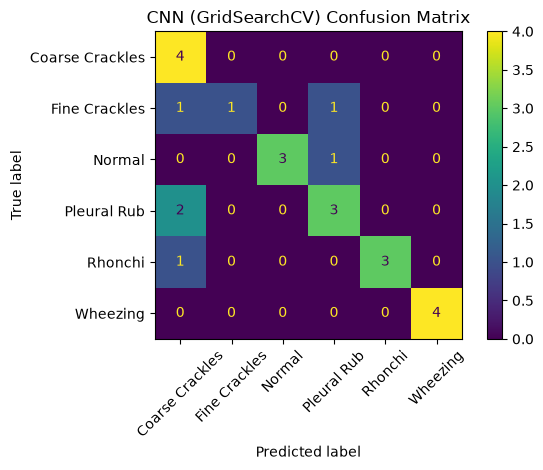

In [13]:
best_cnn = cnn_grid.best_estimator_
cnn_grid_pred = best_cnn.predict(Xc_test)

print(classification_report(yc_test, cnn_grid_pred, target_names=CLASSES, zero_division=0))
ConfusionMatrixDisplay.from_predictions(yc_test, cnn_grid_pred, display_labels=CLASSES, xticks_rotation=45)
plt.title("CNN (GridSearchCV) Confusion Matrix")
plt.tight_layout()
plt.show()

## Manual CNN Training Loop

The cells below (`Train/test split` through the confusion matrix) are the original fixed-hyperparameter manual training loop.

## Train/test split

The split is stratified so each class keeps approximately the same proportion in training and testing. The small dataset makes this important: without stratification, a rare class could be underrepresented in the test set.

In [14]:
# labels = [label for _, label in recs]
# train_recs, test_recs = train_test_split(
#     recs,
#     test_size=0.25,
#     random_state=RANDOM_STATE,
#     stratify=labels,
# )

# train_loader = DataLoader(LungSounds(train_recs), batch_size=16, shuffle=True)
# test_loader = DataLoader(LungSounds(test_recs), batch_size=32, shuffle=False)

# print(f"train samples: {len(train_recs)}")
# print(f"test samples:  {len(test_recs)}")

## Training loop

`CrossEntropyLoss` is used because this is a multi-class classification problem. The CNN outputs raw logits, and the loss function internally applies the softmax operation needed for class probabilities.

In [15]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = LungCNN().to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# def run_epoch(loader, training):
#     model.train(training)
#     total_loss, correct, total = 0.0, 0, 0

#     for x, y in loader:
#         x = x.to(device).float()
#         y = y.to(device).long()

#         with torch.set_grad_enabled(training):
#             logits = model(x)
#             loss = criterion(logits, y)

#             if training:
#                 optimizer.zero_grad()
#                 loss.backward()
#                 optimizer.step()

#         total_loss += loss.item() * x.size(0)
#         correct += (logits.argmax(dim=1) == y).sum().item()
#         total += y.size(0)

#     return total_loss / total, correct / total

# history = []
# EPOCHS = 100
# PATIENCE = 10
# best_test_acc = 0.0
# best_epoch = 0
# best_state = None
# epochs_without_improvement = 0

# for epoch in range(1, EPOCHS + 1):
#     train_loss, train_acc = run_epoch(train_loader, training=True)
#     test_loss, test_acc = run_epoch(test_loader, training=False)
#     history.append({
#         "epoch": epoch,
#         "train_loss": train_loss,
#         "train_acc": train_acc,
#         "test_loss": test_loss,
#         "test_acc": test_acc,
#     })

#     if test_acc > best_test_acc:
#         best_test_acc = test_acc
#         best_epoch = epoch
#         best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
#         epochs_without_improvement = 0
#     else:
#         epochs_without_improvement += 1

#     if epoch == 1 or epoch % 10 == 0:
#         print(
#             f"epoch {epoch:03d} | "
#             f"train loss {train_loss:.3f}, acc {train_acc:.3f} | "
#             f"test loss {test_loss:.3f}, acc {test_acc:.3f} | "
#             f"best test acc {best_test_acc:.3f} at epoch {best_epoch}"
#         )

#     if epochs_without_improvement >= PATIENCE:
#         print(f"Early stopping at epoch {epoch}; best test acc {best_test_acc:.3f} at epoch {best_epoch}")
#         break

# if best_state is not None:
#     model.load_state_dict(best_state)
#     model.to(device)

## Evaluation

The final cells report per-class precision/recall/F1, plot training curves, and show a labeled confusion matrix. These are more useful than accuracy alone because the dataset is small and the model may perform better on some lung sound types than others.

In [16]:
# model.eval()
# y_true, y_pred = [], []

# with torch.no_grad():
#     for x, y in test_loader:
#         logits = model(x.to(device).float())
#         preds = logits.argmax(dim=1).cpu().numpy()
#         y_pred.extend(preds.tolist())
#         y_true.extend(y.numpy().tolist())

# cm = confusion_matrix(y_true, y_pred)
# print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))

In [17]:
# history_df = pd.DataFrame(history)

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
# axes[0].plot(history_df["epoch"], history_df["test_loss"], label="Test")
# axes[0].set_title("Loss")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Cross-entropy loss")
# axes[0].legend()

# axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train")
# axes[1].plot(history_df["epoch"], history_df["test_acc"], label="Test")
# axes[1].set_title("Accuracy")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("Accuracy")
# axes[1].set_ylim(0, 1)
# axes[1].legend()

# plt.tight_layout()
# plt.show()

In [18]:
# ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", xticks_rotation=45)
# plt.title("Confusion Matrix")
# plt.tight_layout()
# plt.show()

## Model Comparison: MLP vs CNN

Both tuned models (`best_mlp` from `GridSearchCV` over the pooled features, `best_cnn` from `GridSearchCV` over the full spectrograms) are scored on their respective held-out test sets.

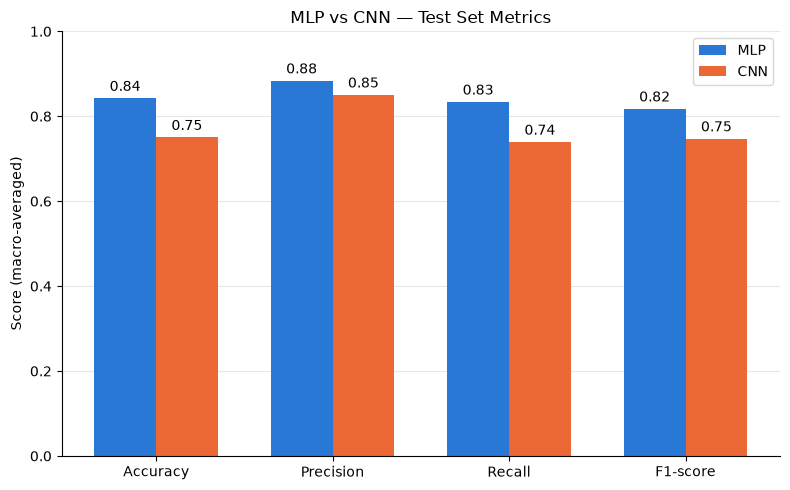

In [19]:
mlp_report = classification_report(y_test, mlp_pred, target_names=CLASSES, output_dict=True, zero_division=0)
cnn_report = classification_report(yc_test, cnn_grid_pred, target_names=CLASSES, output_dict=True, zero_division=0)

metric_labels = ["Accuracy", "Precision", "Recall", "F1-score"]
mlp_scores = [
    mlp_report["accuracy"],
    mlp_report["macro avg"]["precision"],
    mlp_report["macro avg"]["recall"],
    mlp_report["macro avg"]["f1-score"],
]
cnn_scores = [
    cnn_report["accuracy"],
    cnn_report["macro avg"]["precision"],
    cnn_report["macro avg"]["recall"],
    cnn_report["macro avg"]["f1-score"],
]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
mlp_bars = ax.bar(x - width/2, mlp_scores, width, label="MLP", color="#2a78d6")
cnn_bars = ax.bar(x + width/2, cnn_scores, width, label="CNN", color="#eb6834")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score (macro-averaged)")
ax.set_title("MLP vs CNN — Test Set Metrics")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
ax.bar_label(mlp_bars, fmt="%.2f", padding=3)
ax.bar_label(cnn_bars, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()